# COVID-19 Vaccine data

The dataset I've used contains vaccination data for Ontario, canada,  from January 1, 2021, to November 21, 2024. [description](https://data.ontario.ca/dataset/covid-19-vaccine-data-in-ontario/resource/8a89caa9-511c-4568-af89-7f2174b4378c) and [click here for the datasets](https://data.ontario.ca/dataset/752ce2b7-c15a-4965-a3dc-397bf405e7cc/resource/8a89caa9-511c-4568-af89-7f2174b4378c/download/vaccine_doses.csv). It includes daily and cumulative metrics such as doses administered, indiviual vaccinated, doses by vaccination status (e.g., partially vaccinated, fully vaccinated, and third doses). 

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import seaborn as sns

In [26]:
# Define font properties
font = FontProperties()
font.set_family('serif')
font.set_name('Times New Roman')

In [27]:
# Load the data into a pandas dataFrame
df = pd.read_csv('datasets/vaccine_doses.csv')
# Display the first few rows of the original dataframe
print(f'Original DataFrame: {df.shape} \n')
df

Original DataFrame: (1421, 11) 



,report_date,previous_day_total_doses_administered,previous_day_at_least_one,previous_day_fully_vaccinated,previous_day_3doses,total_doses_administered,total_individuals_at_least_one,total_individuals_partially_vaccinated,total_doses_in_fully_vaccinated_individuals,total_individuals_fully_vaccinated,total_individuals_3doses
0,2021-01-01,6256.0,6246.0,2.0,NaN,32275,32218,32207,22.0,11,NaN
1,2021-01-02,4618.0,4606.0,6.0,NaN,36893,36772,36759,26.0,13,NaN
2,2021-01-03,5400.0,5392.0,4.0,NaN,42293,42162,42147,30.0,15,NaN
3,2021-01-04,5998.0,5995.0,0.0,NaN,48291,48156,48142,28.0,14,NaN
4,2021-01-05,9693.0,9668.0,21.0,NaN,57984,57822,57788,68.0,34,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1416,2024-11-17,15569.0,316.0,161.0,361.0,42725586,12607850,491260,NaN,12116590,7665641.0
1417,2024-11-18,8210.0,176.0,101.0,225.0,42733796,12608026,491335,NaN,12116691,7665866.0
1418,2024-11-19,28777.0,464.0,161.0,392.0,42762573,12608482,491638,NaN,12116844,7666252.0
1419,2024-11-20,27195.0,352.0,146.0,405.0,42789768,12608834,491844,NaN,12116990,7666657.0


### Accessing the extent of missing data

In [28]:
# Calculate the number of missing values in each column
missing_values = df.isna().sum()
# Display the missing values
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
report_date                                       0
previous_day_total_doses_administered             4
previous_day_at_least_one                         4
previous_day_fully_vaccinated                     4
previous_day_3doses                             341
total_doses_administered                          0
total_individuals_at_least_one                    0
total_individuals_partially_vaccinated            0
total_doses_in_fully_vaccinated_individuals    1084
total_individuals_fully_vaccinated                0
total_individuals_3doses                        337
dtype: int64


##  Impute Missing Values

**Dataset Overview:**
-  **Rows:** 1,421
- **Columns:** 11
- **Date Range:** The report_date column contains dates (likely daily reports).
- **Missing Values:** Some columns, such as previous_day_3doses, total_doses_in_fully_vaccinated_individuals, and total_individuals_3doses, have missing data.
-  **Data Types:** Most columns are numerical (int64 or float64), while report_date is a string (needs conversion to datetime).

# Visualize Key Trends
Creating a visualization to understand the trends in vaccination data

In [29]:
plt.style.use('ggplot')

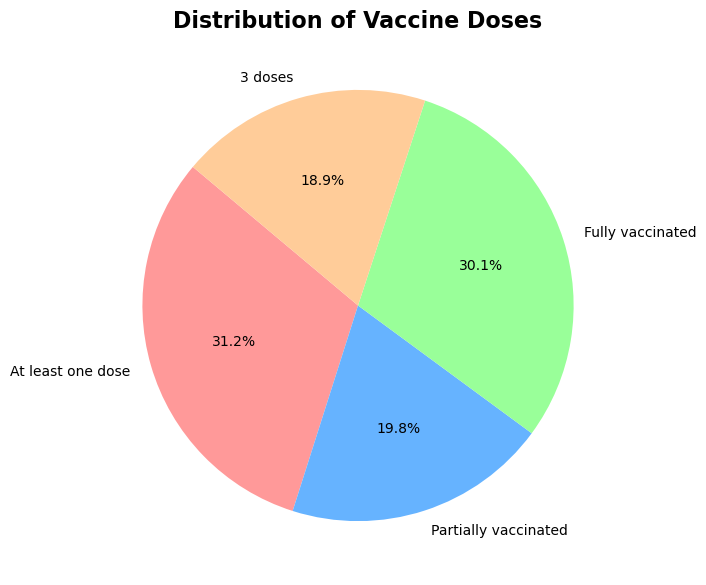

In [30]:
# Aggregating total doses for pie chart
pie_data = {
    'At least one dose': df['total_individuals_at_least_one'].max(),
    'Partially vaccinated': df['total_individuals_partially_vaccinated'].max(),
    'Fully vaccinated': df['total_individuals_fully_vaccinated'].max(),
    '3 doses': df['total_individuals_3doses'].max()
}

# Removing NaN values
pie_data = {k: v for k, v in pie_data.items() if pd.notnull(v)}

# Plotting
fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(pie_data.values(), 
       labels=pie_data.keys(), 
       autopct='%1.1f%%', 
       startangle=140, 
       colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'],
       #textprops={'fontweight': 'bold'},
       )
ax.set_title('Distribution of Vaccine Doses', fontweight='bold', fontsize=16)
plt.show()
